In [1]:
import mujoco
import mujoco.viewer

from QuinticPolynomial import create_quintic_trajectory, QuinticPolynomial
from scipy.spatial.transform import Rotation as R, Slerp
import numpy as np
from icecream import ic
import open3d as o3d
import matplotlib.pyplot as plt


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [6]:
def mujoco2normal(q):
    return np.array([q[1], q[2], q[3], q[0]])

def normal2mujoco(q):
    return np.array([q[3], q[0], q[1], q[2]])

def slerp(x_init_quat, x_final_quat, final_n, n_steps):
    x_init_quat = mujoco2normal(x_init_quat)
    x_final_quat = mujoco2normal(x_final_quat)
    
    rot_times = np.array([0, final_n])
    rots = R.from_quat([x_init_quat, x_final_quat])
    
    slerp = Slerp(rot_times, rots)
    times = np.linspace(0, final_n, n_steps)
    quats = slerp(times).as_quat()
    quats = np.array([normal2mujoco(q) for q in quats])
    quat_dot = np.diff(quats, axis=0) / (final_n / n_steps)
    quat_ddot = np.diff(quat_dot, axis=0) / (final_n / n_steps)
    return quats, quat_dot, quat_ddot 


def quintic_pos(init_pos, final_pos, final_n, nsteps):
    x_poly = QuinticPolynomial(init_pos[0], np.array([0.0]), np.array([0.0]),
                               final_pos[0], np.array([0.0]), np.array([0.0]), nsteps)
    
    ic(x_poly.a_0, x_poly.a_1, x_poly.a_2, x_poly.a_3, x_poly.a_4, x_poly.a_5)
    
    y_poly = QuinticPolynomial(init_pos[1], np.array([0.]), np.array([0.]), final_pos[1],
                               np.array([0.]), np.array([0.]), nsteps)
    z_poly = QuinticPolynomial(init_pos[2], np.array([0.]), np.array([0.]),
                               final_pos[2], np.array([0.]), np.array([0.]), nsteps)

    times = np.linspace(0, final_n, nsteps)
    pos_ref = np.vstack([x_poly.calc_point(times),
                         y_poly.calc_point(times), 
                         z_poly.calc_point(times)]).T
    pos_dot_ref = np.vstack([x_poly.calc_first_derivative(times),
                             y_poly.calc_first_derivative(times),
                             z_poly.calc_first_derivative(times)]).T
    pos_ddot_ref = np.vstack([x_poly.calc_second_derivative(times),
                              y_poly.calc_second_derivative(times),
                              z_poly.calc_second_derivative(times)]).T
    
    return pos_ref, pos_dot_ref, pos_ddot_ref

# ic(slerp([1,0,0,0], [0,1,0,0], 100).shape)

end_effector_quat = np.array([0, 0, 0, 1])
x_init = np.array([0, 0, 0.]).reshape(-1, 1)
x_final = np.array([5, -10, -8.]).reshape(-1, 1)

quat_ref, quat_dot_ref, quat_ddot_ref = slerp(end_effector_quat, end_effector_quat, 500, 500)
pos_ref, pos_dot_ref, pos_ddot_ref = quintic_pos(x_init, x_final, 500, 500)
ic(quat_ref.shape, quat_dot_ref.shape, quat_ddot_ref.shape)
ic(pos_ref.shape, pos_dot_ref.shape, pos_ddot_ref.shape)



ic| x_poly.a_0: array([0.])
    x_poly.a_1: array([0.])
    x_poly.a_2: array([0.])
    x_poly.a_3: array([4.e-07])
    x_poly.a_4: array([-1.2e-09])
    x_poly.a_5: array([9.6e-13])
ic| quat_ref.shape: (500, 4)
    quat_dot_ref.shape: (499, 4)
    quat_ddot_ref.shape: (498, 4)
ic| pos_ref.shape: (500, 3)
    pos_dot_ref.shape: (500, 3)
    pos_ddot_ref.shape: (500, 3)


((500, 3), (500, 3), (500, 3))

In [5]:
# plot all the points in open3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pos_ref)
# add a frame 
frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1, origin=x_init.flatten())
frame2 = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1, origin=x_final.flatten())
o3d.visualization.draw_geometries([pcd, frame, frame2])


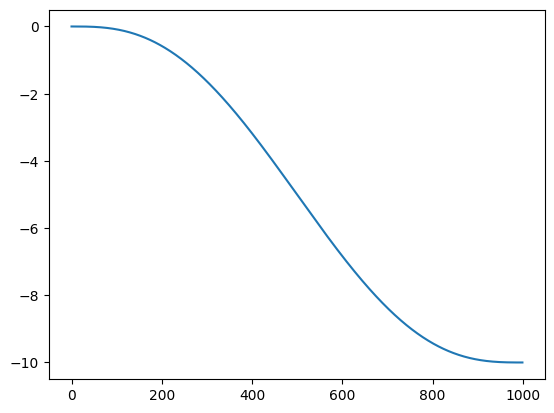

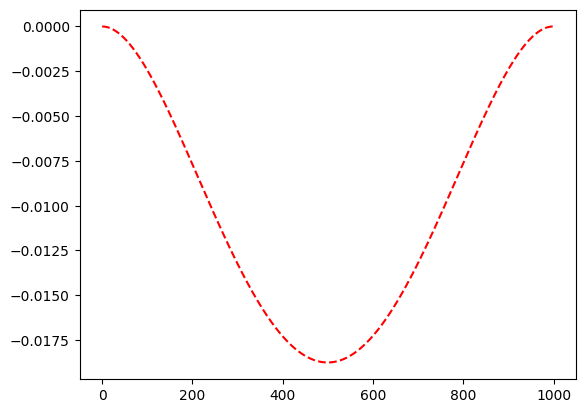

In [32]:
plt.plot(pos_ref[:, 1])
plt.show()
plt.plot(pos_dot_ref[:, 1], '--r')
plt.show()

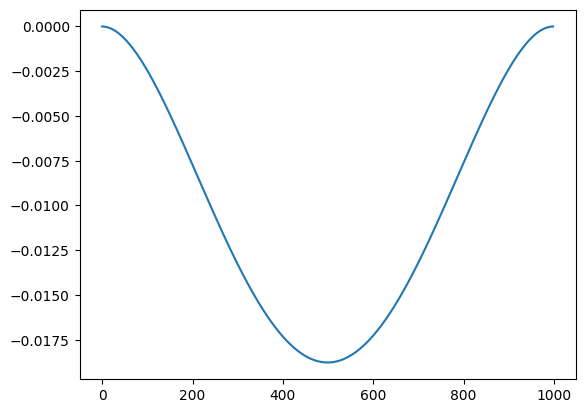

In [41]:
plt.plot(np.diff(pos_ref, axis=0)[:, 1])